# 04 — Caso C: direzione condivisa e spettro di energia gerarchico

**Assunzioni:** (1) sorgente unica; (2) direzione circa costante; (3) energie simili,
$E_n^{(k)}\sim N(\mu_E,\sigma_E)$; scattering isotropo in CM e risoluzione angolare come nel Caso B.
Parametri condivisi: $\Omega_n$ e gli iperparametri $(\mu_E,\sigma_E)$. Le $E_n^{(k)}$ sono
nuisance per evento.

Una griglia 4D bruta su $(\Omega_n,\mu_E,\sigma_E)$ sarebbe troppo costosa. Si procede quindi in
**due stadi**:

1. **stadio 1**: si stima $\Omega_n$ dal posterior combinato del Caso B (prior largo su $E_n$),
   raffinato su una calotta locale;
2. **stadio 2**: con $\Omega_n$ fissato, si calcola il posterior 2D su $(\mu_E,\sigma_E)$. La
   griglia globale ($\mu_E$ lineare, $\sigma_E$ logaritmica) viene poi raffinata sulla finestra
   dove sta la massa.

Lo stadio 1 usa $\hat\Omega_n$ come stima puntuale (plug-in): la sua incertezza non viene
propagata allo stadio 2. Se questa approssimazione basti lo dice la coverage (notebook 05).

**Etichette dei risultati.** (a) fatto consolidato · (b) stima toy con assunzioni esplicite ·
(c) verificato con Monte Carlo · (d) ipotesi da testare.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
from scipy.stats import kstest, norm

from riptide_toy.constants import SEED, SIGMA_EP, SIGMA_THETA, EN_MIN, EN_MAX

plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(SEED)
from riptide_toy import combine, forward_model, grids, kinematics, posterior_C, priors, validate

MU_TRUE, SIGMA_TRUE, N = 3.0, 0.4, 300
OMEGA_TRUE = kinematics.direction_from_theta_phi(np.array([0.9]), np.array([2.1]))

Ep, track = kinematics.sample_recoil_events(rng, rng.normal(MU_TRUE, SIGMA_TRUE, N), OMEGA_TRUE[0])
D_B = (rng.normal(Ep, SIGMA_EP), kinematics.smear_direction(rng, track, SIGMA_THETA))

## Stadio 1 — direzione

In [2]:
theta_grid, phi_grid = grids.sphere_grid()
omega_hat, cap_lp, cap_th, cap_ph = posterior_C.refine_shared_direction(
    D_B, theta_grid, phi_grid, priors.direction_prior(theta_grid, phi_grid))
cap = kinematics.direction_from_theta_phi(cap_th, cap_ph)
err = validate.angular_residual(OMEGA_TRUE, omega_hat)[0]
res = validate.posterior_angular_resolution(cap_lp[None, :], cap, omega_hat)[0]
print(f"errore su Omega_n: {np.degrees(err):.2f} gradi, risoluzione del posterior {np.degrees(res):.2f} gradi")

errore su Omega_n: 2.01 gradi, risoluzione del posterior 1.57 gradi


## Stadio 2 — iperparametri dello spettro

Per ogni $(\mu_E,\sigma_E)$ la verosimiglianza dell'evento marginalizza $E_n^{(k)}$ sotto la
gaussiana $N(\mu_E,\sigma_E)$, troncata e rinormalizzata sul dominio 0.5–6 MeV. Prima si mostra la
griglia globale 60×60, poi quella raffinata.

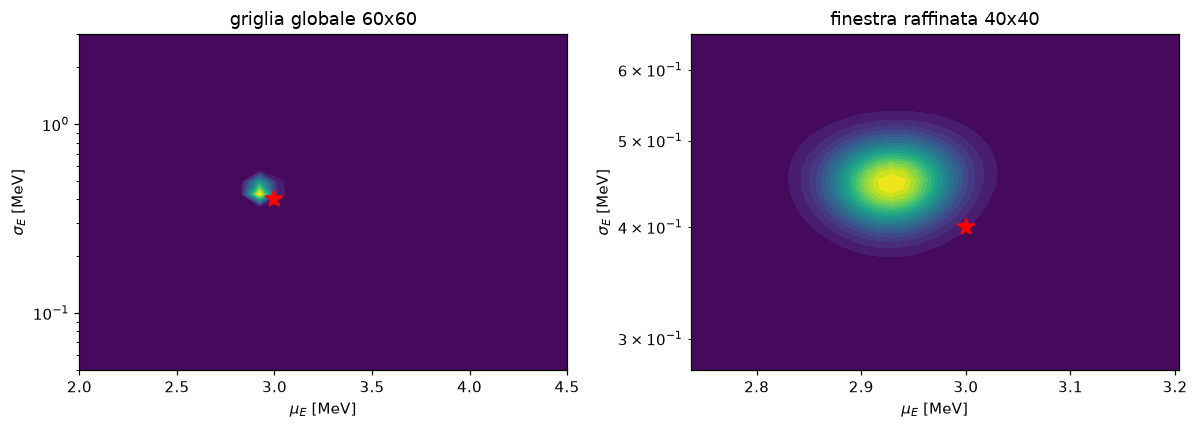

mu_E    = 2.930 +- 0.040 MeV   (vero 3.0)
sigma_E = 0.449 MeV, 68%: [0.416, 0.485]   (vero 0.4)


In [3]:
D = (*D_B, omega_hat)
mu_grid, sigma_grid = grids.hyperparameter_grid()
coarse = posterior_C.shared_hyperparameter_log_posterior(
    D, mu_grid, sigma_grid, priors.hyperparameter_prior(mu_grid, sigma_grid))
log_post, mu_f, sigma_f = posterior_C.refine_hyperparameters(D, mu_grid, sigma_grid, priors.hyperparameter_prior)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (lp, mu, sg, title) in zip(axes, [(coarse, mu_grid, sigma_grid, "griglia globale 60x60"),
                                           (log_post, mu_f, sigma_f, "finestra raffinata 40x40")]):
    n_mu = np.unique(mu).size
    Z = np.exp(lp - lp.max()).reshape(n_mu, -1)
    ax.contourf(mu.reshape(n_mu, -1), sg.reshape(n_mu, -1), Z, levels=20)
    ax.plot(MU_TRUE, SIGMA_TRUE, "r*", ms=12)
    ax.set_yscale("log"); ax.set_xlabel(r"$\mu_E$ [MeV]"); ax.set_ylabel(r"$\sigma_E$ [MeV]"); ax.set_title(title)
axes[0].set_xlim(2, 4.5); axes[0].set_ylim(0.05, 3)
plt.tight_layout(); plt.show()

mu_m, mu_s = validate.posterior_mean_std(log_post[None, :], mu_f)
q = validate.credible_interval(log_post[None, :], np.log(sigma_f), np.array([0.0, 0.68]))[0]
print(f"mu_E    = {mu_m[0]:.3f} +- {mu_s[0]:.3f} MeV   (vero {MU_TRUE})")
print(f"sigma_E = {np.exp(q[0, 0]):.3f} MeV, 68%: [{np.exp(q[1, 0]):.3f}, {np.exp(q[1, 1]):.3f}]   (vero {SIGMA_TRUE})")

Questa è **una sola realizzazione**. Scarti di 1–2 deviazioni standard dal valore vero (per
esempio $\mu_E$ un po' basso o $\sigma_E$ appena fuori dall'intervallo al 68%) sono attesi in una
frazione non trascurabile dei casi, e in più $\hat\Omega_n$ è usato come plug-in. Se gli
intervalli siano calibrati si giudica solo su molte ripetizioni: è il compito della checklist
del notebook 05.

Per $\sigma_E$ si usa come stima la **mediana** del posterior in $\log\sigma_E$. La media pesata è
sensibile alla coda verso $\sigma_E$ grandi, dove la verosimiglianza diventa piatta: con pochi
eventi, un allargamento dello spettro è difficile da distinguere dall'effetto della cinematica.

Sulla griglia globale il passo in $\mu_E$ è circa 0.09 MeV, confrontabile con la larghezza del
posterior a N di qualche centinaio. Senza raffinamento la stima e soprattutto la sua incertezza
sarebbero dominate dalla discretizzazione.

## Casi limite: C contiene A e B

* $\sigma_E\to\infty$: il prior gerarchico su $E_n$ diventa piatto sul dominio, quindi la
  verosimiglianza per evento deve coincidere con quella del Caso B **(c)**;
* $\sigma_E\to 0$: tutti gli eventi hanno la stessa energia, come nel Caso A, e $\mu_E$ deve
  ricostruire l'energia comune **(c)**.

In [4]:
en_grid = grids.energy_grid()
theta_obs = kinematics.recoil_angle_from_direction(D_B[1], OMEGA_TRUE)[:, 0]
hier = forward_model.loglik_marginal_En_theta_hierarchical(
    D_B[0], theta_obs, en_grid, SIGMA_EP, SIGMA_THETA,
    priors.log_energy_prior_given_hyperparams(en_grid, np.array([3.25]), np.array([1000.0])))
flat = forward_model.loglik_marginal_En_theta(
    D_B[0], theta_obs[:, None], en_grid, SIGMA_EP, SIGMA_THETA, np.log(priors.energy_prior(en_grid)))
print(f"sigma_E = 1000 MeV vs Caso B: max |differenza di log L| = {np.max(np.abs(hier - flat)):.2e}")

sigma_E = 1000 MeV vs Caso B: max |differenza di log L| = 2.19e-04


sigma_E minimo della griglia = 0.010 MeV
MAP di mu_E a sigma_E minimo: 2.458 MeV   (vero 2.5)


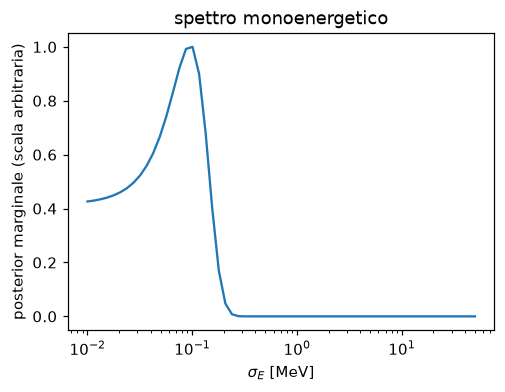

In [5]:
EN_SHARED = 2.5
Ep0, track0 = kinematics.sample_recoil_events(rng, np.full(100, EN_SHARED), OMEGA_TRUE[0])
D0 = (rng.normal(Ep0, SIGMA_EP), kinematics.smear_direction(rng, track0, SIGMA_THETA), OMEGA_TRUE)
lp0 = posterior_C.shared_hyperparameter_log_posterior(
    D0, mu_grid, sigma_grid, priors.hyperparameter_prior(mu_grid, sigma_grid)).reshape(60, 60)
mu_1d, sigma_1d = mu_grid.reshape(60, 60)[:, 0], sigma_grid.reshape(60, 60)[0]
print(f"sigma_E minimo della griglia = {sigma_1d[0]:.3f} MeV")
print(f"MAP di mu_E a sigma_E minimo: {mu_1d[np.argmax(lp0[:, 0])]:.3f} MeV   (vero {EN_SHARED})")
marg_sigma = np.exp(lp0 - lp0.max()).sum(axis=0)
plt.figure(figsize=(5, 3.5))
plt.semilogx(sigma_1d, marg_sigma / marg_sigma.max())
plt.xlabel(r"$\sigma_E$ [MeV]"); plt.ylabel("posterior marginale (scala arbitraria)")
plt.title("spettro monoenergetico"); plt.show()

Con uno spettro monoenergetico, il posterior marginale su $\sigma_E$ è piatto sotto una certa
scala e cala sopra. I dati dicono solo che $\sigma_E$ è piccolo rispetto alla risoluzione: sotto
circa $\sigma_{E_p}$ lo scatter fra eventi non si distingue dal rumore di misura. È il
comportamento atteso, e per questo $\sigma_E$ va riportato come limite superiore, non come
valore puntuale, quando è piccolo.